#==========================================================
# Task 7: Evaluation & Explainability 
#==========================================================

In [1]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

/home/sundayofunmi/.pandas_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load model and data
model_pipe = joblib.load("best_model.pkl")
df = pd.read_csv("processed_disasters.csv")
X = df[['declaration_year', 'region', 'project_count', 'avg_project_amount', 'incidentType', 'state', 'season']]


In [3]:
# Transform data for SHAP (SHAP often needs the array output from the preprocessor)
X_processed = model_pipe.named_steps['prep'].transform(X)
# Get feature names from the OneHotEncoder
cat_names = model_pipe.named_steps['prep'].transformers_[1][1].get_feature_names_out()
all_features = ['declaration_year', 'region', 'project_count', 'avg_project_amount'] + list(cat_names)


In [4]:
# SHAP Analysis
explainer = shap.Explainer(model_pipe.named_steps['model'])
shap_values = explainer(X_processed)


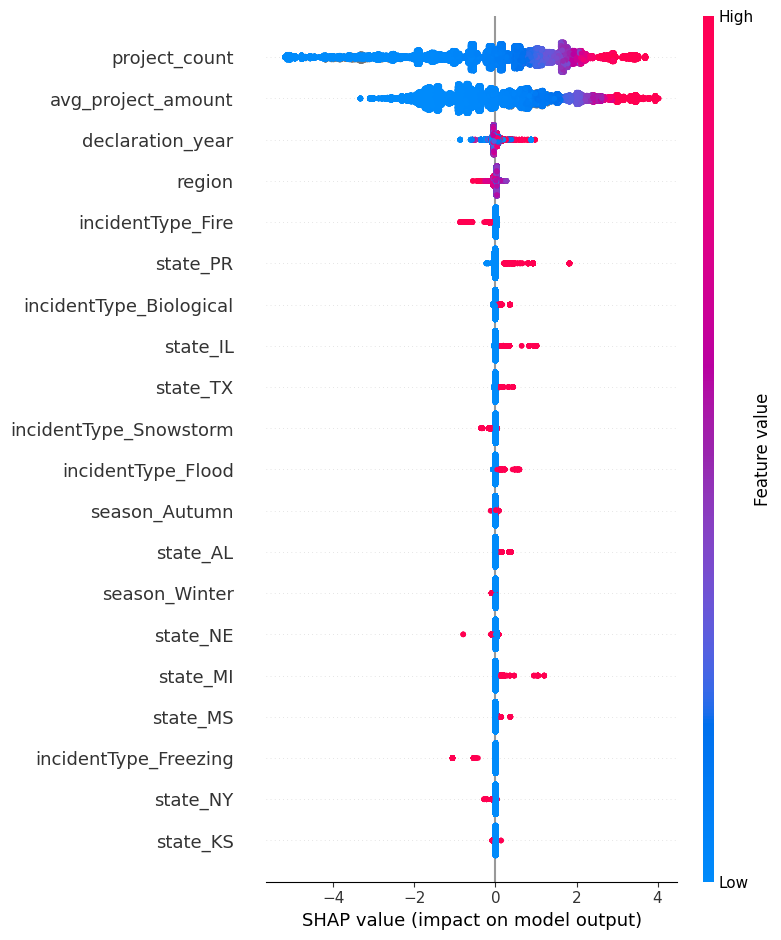

In [5]:
# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_processed, feature_names=all_features, show=False)
plt.savefig("shap_summary.png")
plt.show()


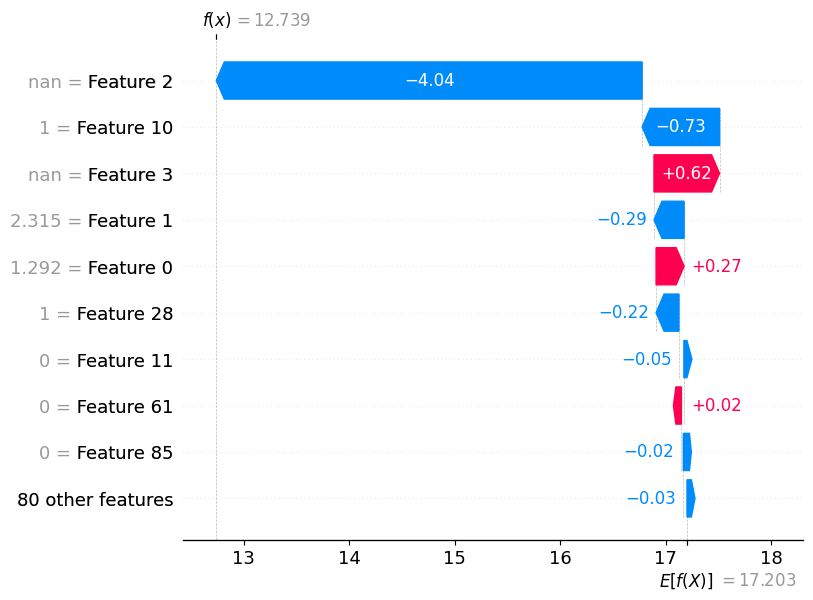

In [7]:
#import shap
#import joblib
#import pandas as pd
#import matplotlib.pyplot as plt

# 1. Load your model and data
#model_pipe = joblib.load("models/best_model.pkl")
#df = pd.read_csv("data/processed/processed_disasters.csv")

# 2. Pick one specific disaster to explain (e.g., the first one in the dataset)
sample_idx = 28 # number 28 is the project_count 
sample_data = df.iloc[[sample_idx]]

# 3. Prepare the data using the model's preprocessor
# We need to transform the raw data into the format the XGBoost model understands
prep = model_pipe.named_steps['prep']
X_transformed = prep.transform(sample_data)
feature_names = prep.get_feature_names_out()

# 4. Generate SHAP values for this specific sample
explainer = shap.Explainer(model_pipe.named_steps['model'])
shap_values = explainer(X_transformed)

# 5. Plot the Waterfall
plt.figure(figsize=(10, 6))
# We use [0] to select the first (and only) sample we passed
shap.plots.waterfall(shap_values[0], max_display=10) 
plt.show()


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38883 entries, 0 to 38882
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   femaDeclarationString     38883 non-null  object 
 1   disasterNumber            38883 non-null  int64  
 2   state                     38883 non-null  object 
 3   declarationType           38883 non-null  object 
 4   declarationDate           38883 non-null  object 
 5   fyDeclared                38883 non-null  int64  
 6   incidentType              38883 non-null  object 
 7   declarationTitle          38883 non-null  object 
 8   ihProgramDeclared         38883 non-null  int64  
 9   iaProgramDeclared         38883 non-null  int64  
 10  paProgramDeclared         38883 non-null  int64  
 11  hmProgramDeclared         38883 non-null  int64  
 12  incidentBeginDate         38883 non-null  object 
 13  incidentEndDate           38870 non-null  object 
 14  disast